In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

vals = np.linspace(1, 0.2, 6)
blues   = [plt.cm.Blues(v)   for v in vals]
purples = [plt.cm.Purples(v) for v in vals]
greens  = [plt.cm.Greens(v)  for v in vals]
grays   = [plt.cm.Greys(v)   for v in vals] 
tab20b = [plt.cm.tab20b(v) for v in vals]
def darken(color, factor=0.6):
    """Darken an RGBA color by a given factor (0–1)."""
    r, g, b, a = color
    return (r * factor, g * factor, b * factor, a)

tab20b_darker = [darken(c, factor=0.6) for c in tab20b]

# Gal1 is a galaxy with all default values.

m_o_cc = 0.015

In [19]:
t_array = np.linspace(0,12,int(1e3))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_const = np.ones(len(t_array))

#Gal1, with everything
gal1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp)
Z_Fe_1 = gal1.compute_z_Fe()
Z_O_1 = gal1.compute_z_O()
Z_Mn_1 = gal1.compute_z_Mn()
Z_X = gal1.compute_z_X()

O_eq = gal1.analytic_eq_O(SFR_function='exponential')
m_o_cc_solar = gal1.m_o_cc_arr[0] * gal1.SolarO/O_eq
print("m_o_cc to get solar values = ", m_o_cc_solar)

gal1_1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, m_o_cc=m_o_cc_solar)

m_o_cc to get solar values =  0.01642666666666667


# Gal2 is a galaxy with m_o_cc = 0.012, to match solar metallicity, with other parameters being the same.

In [20]:
#Gal1, with everything
gal2 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, m_o_cc=0.75 * gal1.m_o_cc_arr[0])

# Now I look at the contribution of CC to total Iron mass in Gal1, to get R_Ia_Fe values.

Text(0, 0.5, 'M_Fe')

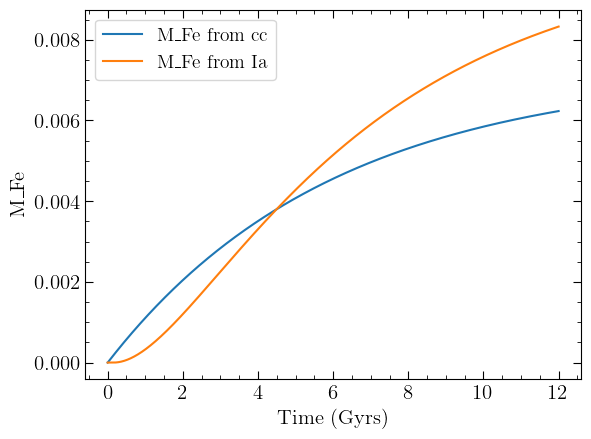

In [21]:
plt.plot(t_array, gal1.m_Fe_from_cc, label = 'M_Fe from cc')
plt.plot(t_array, gal1.m_Fe_from_Ia, label = 'M_Fe from Ia')

plt.legend()
plt.xlabel('Time (Gyrs)')
plt.ylabel('M_Fe')

In [22]:
m_tot_Fe_cc = np.sum(gal1.m_Fe_from_cc)
m_tot_Fe_Ia = np.sum(gal1.m_Fe_from_Ia)
R_Ia_Fe = m_tot_Fe_Ia/m_tot_Fe_cc
print("R_Ia_Fe = ", R_Ia_Fe)

R_Ia_Fe =  1.1360195017030525


# Now I attempt to get Fe in Gal2, both in the previous manner and in the new one.

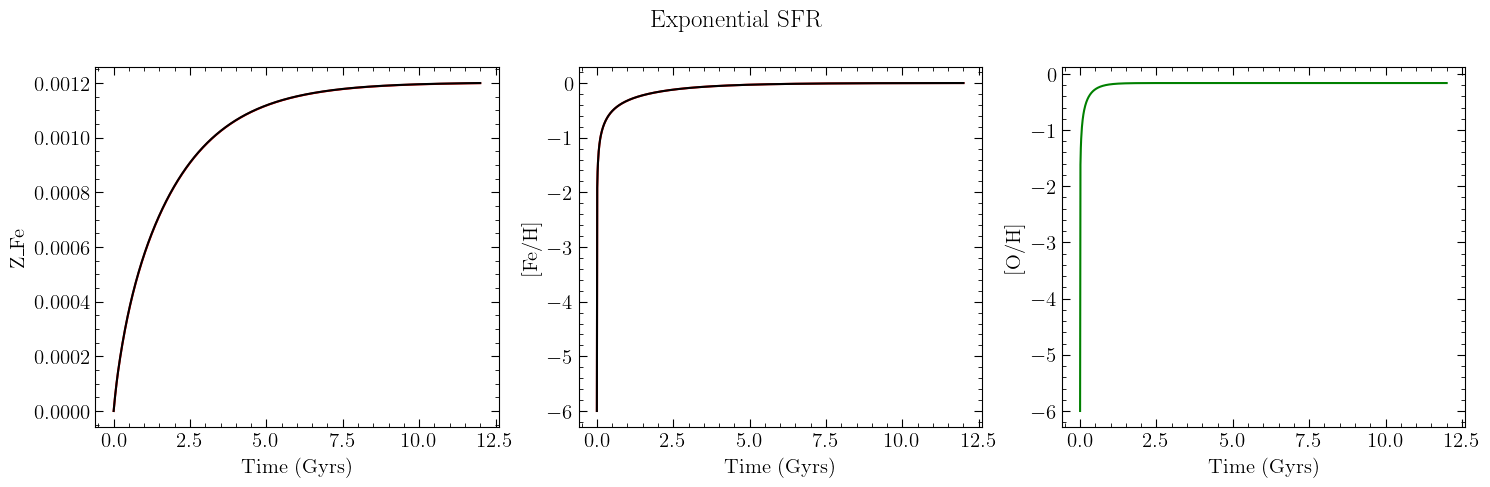

In [23]:
Z_Fe_new_code = gal2.compute_z_X(R_Ia_X=1)
Fe_H_new_code = gal2.ratio_to_sun(Z_Fe_new_code, gal2.SolarFe)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(t_array, gal2.compute_z_Fe(), color = 'red', label = 'Before')
plt.plot(t_array, Z_Fe_new_code, color = 'black', label = 'After')

plt.xlabel('Time (Gyrs)')
plt.ylabel("Z_Fe")

plt.subplot(1,3,2)
plt.plot(t_array, gal2.Fe_H, color = 'red')
plt.plot(t_array, Fe_H_new_code, color = 'black')
plt.xlabel("Time (Gyrs)")
plt.ylabel('[Fe/H]')

plt.subplot(1,3,3)
plt.plot(t_array, gal2.O_H, color = 'green')
plt.xlabel('Time (Gyrs)')
plt.ylabel('[O/H]')

plt.suptitle('Exponential SFR')
plt.tight_layout()

# a) Constant SFR

Text(0.5, 1.0, 'Constant SFR')

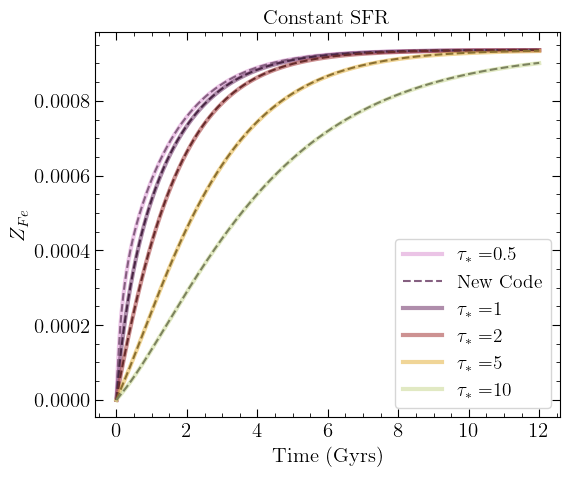

In [24]:
tau_stars = [0.5, 1, 2, 5, 10]

Z_Fe_news = []
Z_Fe_olds = []
Fe_H_news = []
Fe_H_olds = []
O_Hs = []

for tau_star in tau_stars:
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_star, m_o_cc=0.75 * gal1.m_o_cc_arr[0])
    Z_Fe_news.append(gal_temp.compute_z_X(R_Ia_X=1))
    Z_Fe_olds.append(gal_temp.compute_z_Fe())
    Fe_H_news.append(gal_temp.ratio_to_sun(gal_temp.compute_z_X(R_Ia_X=1), gal_temp.SolarFe))
    Fe_H_olds.append(gal_temp.Fe_H)
    O_Hs.append(gal_temp.O_H)

plt.figure(figsize=(6,5))
#plt.subplot(1,3,1)
for i in range(len(tau_stars)):
    plt.plot(t_array, Z_Fe_olds[i], color = tab20b[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3, alpha = 0.6)
    if i == 0:
        plt.plot(t_array, Z_Fe_news[i], color=tab20b_darker[i], label='New Code', linestyle='--', zorder=10)
    else:
        plt.plot(t_array, Z_Fe_news[i], color=tab20b_darker[i], linestyle='--', zorder=10)

plt.legend()
plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{Fe}$")
plt.title("Constant SFR")

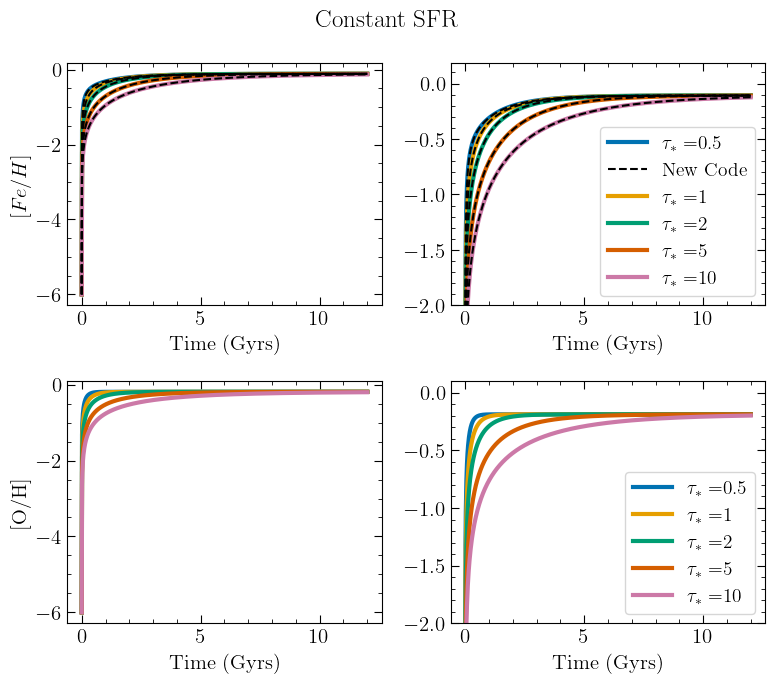

In [25]:
plt.figure(figsize=(8,7))
plt.subplot(2,2,1)
for i in range(len(tau_stars)):
    plt.plot(t_array, Fe_H_olds[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3)
    if i == 0:
        plt.plot(t_array, Fe_H_news[i], color='black', label='New Code', linestyle='--', zorder=10)
    else:
        plt.plot(t_array, Fe_H_news[i], color='black', linestyle='--', zorder=10)


plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$[Fe/H]$")

plt.subplot(2,2,2)
for i in range(len(tau_stars)):
    plt.plot(t_array, Fe_H_olds[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3)
    if i == 0:
        plt.plot(t_array, Fe_H_news[i], color='black', label='New Code', linestyle='--', zorder=10)
    else:
        plt.plot(t_array, Fe_H_news[i], color='black', linestyle='--', zorder=10)

plt.legend()
plt.ylim(-2)
plt.xlabel('Time (Gyrs)')
#plt.ylabel(r"$Z_{Fe}$")

plt.subplot(2,2,3)
for i in range(len(tau_stars)):
    plt.plot(t_array, O_Hs[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3)


plt.xlabel('Time (Gyrs)')
plt.ylabel("[O/H]")

plt.subplot(2,2,4)
for i in range(len(tau_stars)):
    plt.plot(t_array, O_Hs[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3)

plt.legend()
plt.ylim(-2)
plt.xlabel('Time (Gyrs)')
#plt.ylabel(r"$Z_{O}$")
plt.suptitle("Constant SFR")
plt.tight_layout()

Text(0.5, 0.98, 'Constant SFR')

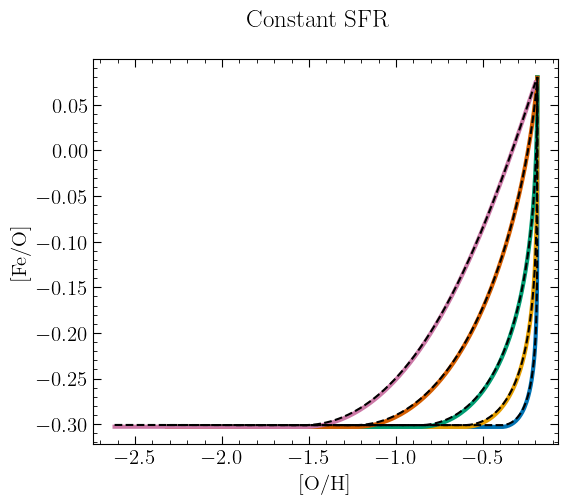

In [26]:
plt.figure(figsize=(6,5))

for i in range(len(tau_stars)):
    plt.plot(O_Hs[i][1:], Fe_H_olds[i][1:] - O_Hs[i][1:], color = colors[i], label = 'Before', lw=3)
    plt.plot(O_Hs[i][1:], Fe_H_news[i][1:] - O_Hs[i][1:], color='black', label='New Code', linestyle='--', zorder=10)
plt.xlabel("[O/H]")
plt.ylabel('[Fe/O]')
plt.suptitle("Constant SFR")

In [27]:
int(len(tau_stars)/2)

2

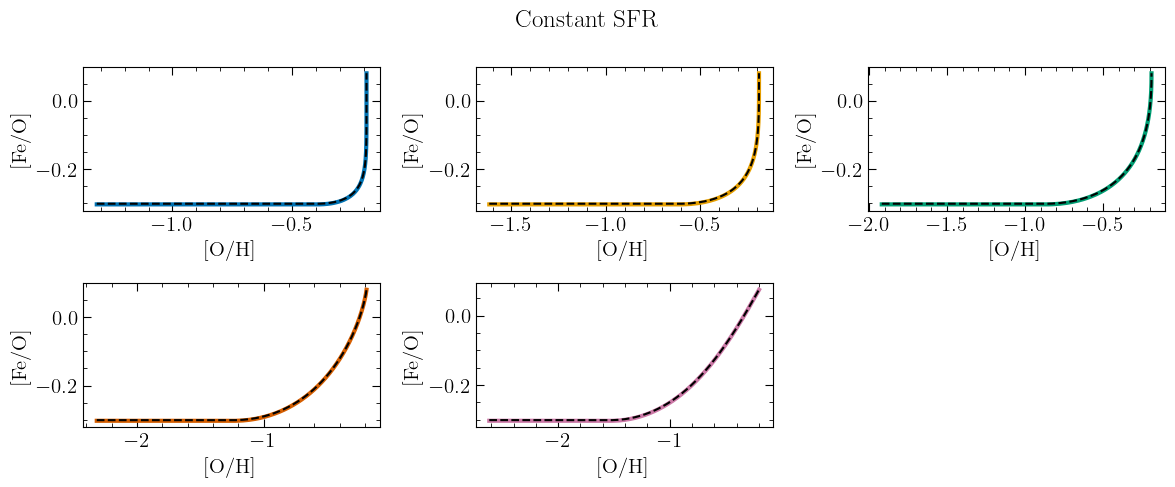

In [28]:
plt.figure(figsize=(12,5))

for i in range(len(tau_stars)):
    plt.subplot(2,int(len(tau_stars)/2)+1, i+1)
    plt.plot(O_Hs[i][1:], Fe_H_olds[i][1:] - O_Hs[i][1:], color = colors[i], label = 'Before', lw=3)
    plt.plot(O_Hs[i][1:], Fe_H_news[i][1:] - O_Hs[i][1:], color='black', label='New Code', linestyle='--', zorder=10)
    plt.xlabel("[O/H]")
    plt.ylabel('[Fe/O]')

plt.suptitle("Constant SFR")
plt.tight_layout()

# b) Exponential SFR

Text(0.5, 1.0, 'Exp SFR')

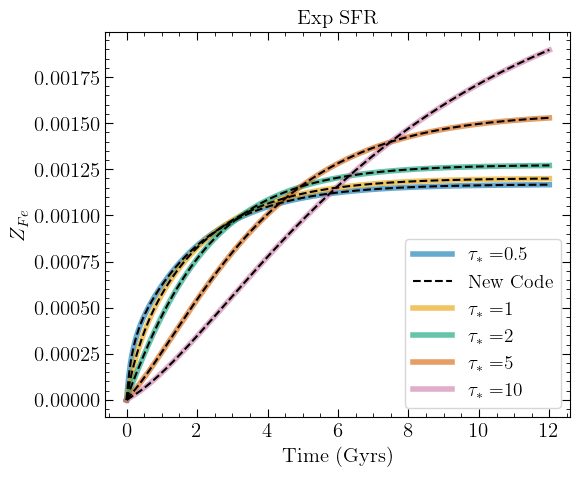

In [29]:
tau_stars = [0.5, 1, 2, 5, 10]

Z_Fe_news = []
Z_Fe_olds = []
Fe_H_news = []
Fe_H_olds = []
O_Hs = []

for tau_star in tau_stars:
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, tau_star=tau_star, m_o_cc=0.75 * gal1.m_o_cc_arr[0])
    Z_Fe_news.append(gal_temp.compute_z_X(R_Ia_X=1))
    Z_Fe_olds.append(gal_temp.compute_z_Fe())
    Fe_H_news.append(gal_temp.ratio_to_sun(gal_temp.compute_z_X(R_Ia_X=1), gal_temp.SolarFe))
    Fe_H_olds.append(gal_temp.Fe_H)
    O_Hs.append(gal_temp.O_H)

plt.figure(figsize=(6,5))
#plt.subplot(1,3,1)
for i in range(len(tau_stars)):
    plt.plot(t_array, Z_Fe_olds[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=4, alpha = 0.6)
    if i == 0:
        plt.plot(t_array, Z_Fe_news[i], color='black', label='New Code', linestyle='--', zorder=10)
    else:
        plt.plot(t_array, Z_Fe_news[i], color='black', linestyle='--', zorder=10)

plt.legend()
plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{Fe}$")
plt.title("Exp SFR")

Text(0.5, 1.0, 'Exp SFR')

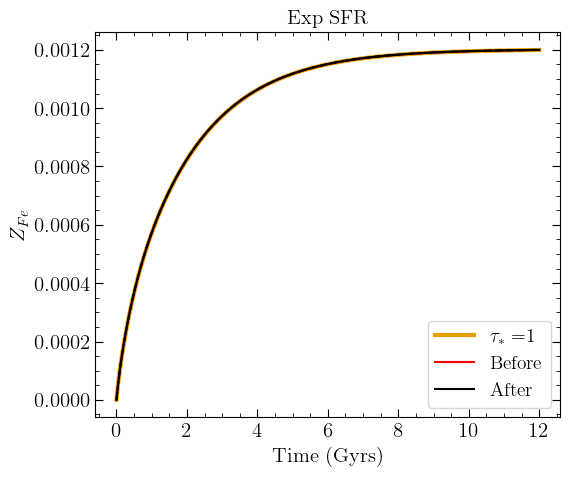

In [30]:
tau_stars = [0.5, 1, 2, 5, 10]

Z_Fe_news = []
Z_Fe_olds = []
Fe_H_news = []
Fe_H_olds = []
O_Hs = []
#Gal1, with everything
gal2 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp)
for tau_star in tau_stars:
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, tau_star=tau_star, m_o_cc=0.75 * gal1.m_o_cc_arr[0])
    Z_Fe_news.append(gal_temp.compute_z_X(R_Ia_X=1))
    Z_Fe_olds.append(gal_temp.compute_z_Fe())
    Fe_H_news.append(gal_temp.ratio_to_sun(gal_temp.compute_z_X(R_Ia_X=1), gal_temp.SolarFe))
    Fe_H_olds.append(gal_temp.Fe_H)
    O_Hs.append(gal_temp.O_H)

plt.figure(figsize=(6,5))
#plt.subplot(1,3,1)
for i in range(len(tau_stars)):
    if tau_stars[i] == 1:
        plt.plot(t_array, Z_Fe_olds[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3)
        if i == 0:
            plt.plot(t_array, Z_Fe_news[i], color='black', label='New Code', linestyle='--', zorder=10)
        else:
            plt.plot(t_array, Z_Fe_news[i], color='black', linestyle='--', zorder=10)

plt.plot(t_array, gal2.compute_z_Fe(), color = 'red', label = 'Before')
plt.plot(t_array, Z_Fe_new_code, color = 'black', label = 'After')
plt.legend()
plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{Fe}$")
plt.title("Exp SFR")

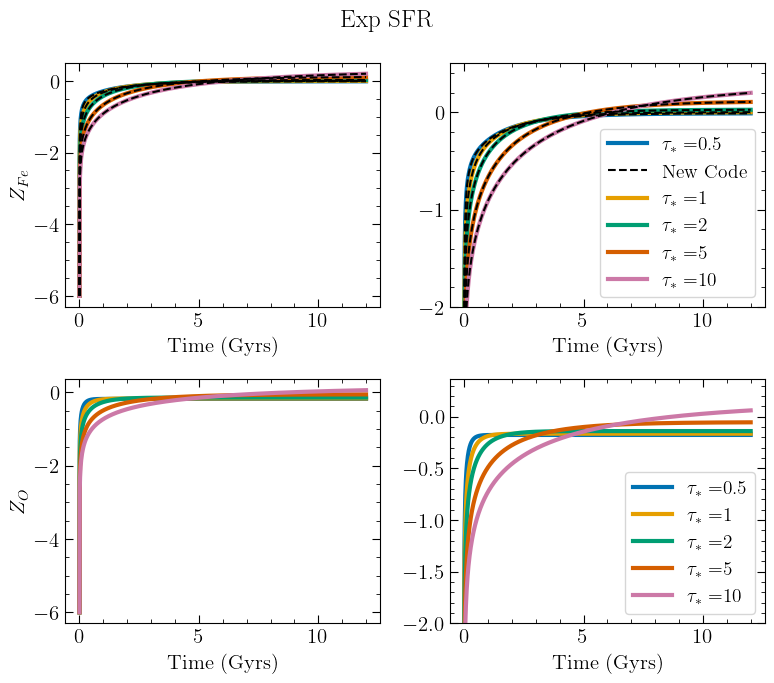

In [31]:
plt.figure(figsize=(8,7))
plt.subplot(2,2,1)
for i in range(len(tau_stars)):
    plt.plot(t_array, Fe_H_olds[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3)
    if i == 0:
        plt.plot(t_array, Fe_H_news[i], color='black', label='New Code', linestyle='--', zorder=10)
    else:
        plt.plot(t_array, Fe_H_news[i], color='black', linestyle='--', zorder=10)


plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{Fe}$")

plt.subplot(2,2,2)
for i in range(len(tau_stars)):
    plt.plot(t_array, Fe_H_olds[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3)
    if i == 0:
        plt.plot(t_array, Fe_H_news[i], color='black', label='New Code', linestyle='--', zorder=10)
    else:
        plt.plot(t_array, Fe_H_news[i], color='black', linestyle='--', zorder=10)

plt.legend()
plt.ylim(-2)
plt.xlabel('Time (Gyrs)')
#plt.ylabel(r"$Z_{Fe}$")

plt.subplot(2,2,3)
for i in range(len(tau_stars)):
    plt.plot(t_array, O_Hs[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3)


plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{O}$")

plt.subplot(2,2,4)
for i in range(len(tau_stars)):
    plt.plot(t_array, O_Hs[i], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=3)

plt.legend()
plt.ylim(-2)
plt.xlabel('Time (Gyrs)')
#plt.ylabel(r"$Z_{O}$")
plt.suptitle("Exp SFR")
plt.tight_layout()

Text(0.5, 0.98, 'Exp SFR')

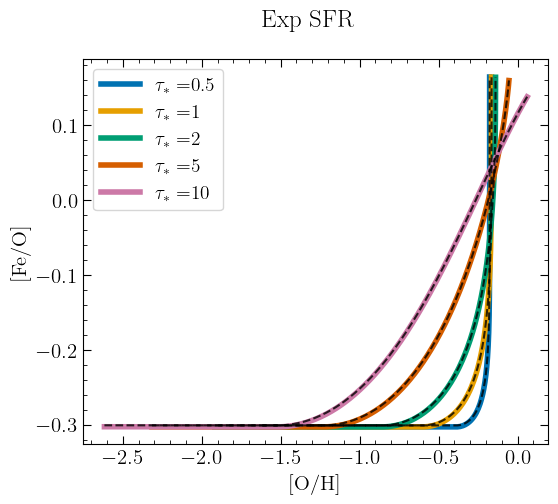

In [35]:
plt.figure(figsize=(6,5))

for i in range(len(tau_stars)):
    plt.plot(O_Hs[i][1:], Fe_H_olds[i][1:] - O_Hs[i][1:], color = colors[i], label = r'$\tau_{*} = $' + f"{tau_stars[i]}", lw=4)
    plt.plot(O_Hs[i][1:], Fe_H_news[i][1:] - O_Hs[i][1:], color='black', linestyle='--', zorder=10, alpha = 0.8)

plt.legend()
plt.xlabel("[O/H]")
plt.ylabel('[Fe/O]')
plt.suptitle("Exp SFR")